# Julián Serrano Chacón
# Mika Rodríguez Castro
  
# Práctica 2

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
import time # para medir tiempos de ejecución
import soundfile as sf     
from ipywidgets import interact
import sys
import scipy.signal as sg

# graficos en el notebook
%matplotlib inline

SRATE = 48000 # Sample rate, para todo el notebook

CHUNK = 2048


class Osc:
    def __init__(self,freq=440.0,amp=1.0,phase=0.0,shape='sin'):
        self.freq = freq
        self.amp = amp
        self.phase = phase
        self.frame = 0
        self.shape = shape

    def next(self):    
        if self.shape=='sin':
            out = np.sin(2*np.pi*(np.arange(self.frame,self.frame+CHUNK))*self.freq/SRATE+self.phase)
        elif self.shape=='square':
            out = sg.square(2*np.pi*(np.arange(self.frame,self.frame+CHUNK))*self.freq/SRATE+self.phase)
        elif self.shape=='sawtooth':
            out = sg.sawtooth(2*np.pi*(np.arange(self.frame,self.frame+CHUNK))*self.freq/SRATE+self.phase)
        elif self.shape=='triangle':
            # Ojo, la triangular no existe como tal en scipy, pero podemos hacerla con dos sawtooth
            # el 2º parametro define la "rampa" la subida y bajada (ver documentacion)
            out = sg.sawtooth(2*np.pi*(np.arange(self.frame,self.frame+CHUNK))*self.freq/SRATE+self.phase,0.5)
        self.frame += CHUNK

        return np.float32(self.amp*out)

#### Ejercicio 1   
(Evaluable) Implementar una clase AMmodulator para modular en amplitud (volumen) una
señal dada signal. La constructora seá de la forma:  
__init__(self,signal,shape=’sin’,freq=1,v0=0,v1=1)  
donde signal es la señal a modular (un objeto generador de señal, i.e., que implementa el método
next) y el resto de parámetros se refieren al modulador:  
• shape: forma de onda del modulador (puede ser sin, saw, square o triangle)  
• freq: la frecuencia del modulador (en Hz)  
• v0,v1: los valores mínimo y máximo de la onda moduladora (en el rango [0,1], donde 0 es
silencio y 1 es el volumen máximo de la señal original). ¿Qué ocurriría si dejamos que v0,v1
estén fuera de ese rango?  
La clase AMmodulator, será a su vez un generador de señal, es decir implementará el método next
para devolver la señal signal modulada. De este modo, podremos por ejemplo moudular una señal
triangular de 440 Hz con un modulador de 2 Hz y amplitud de 0.2 a 0.9:  
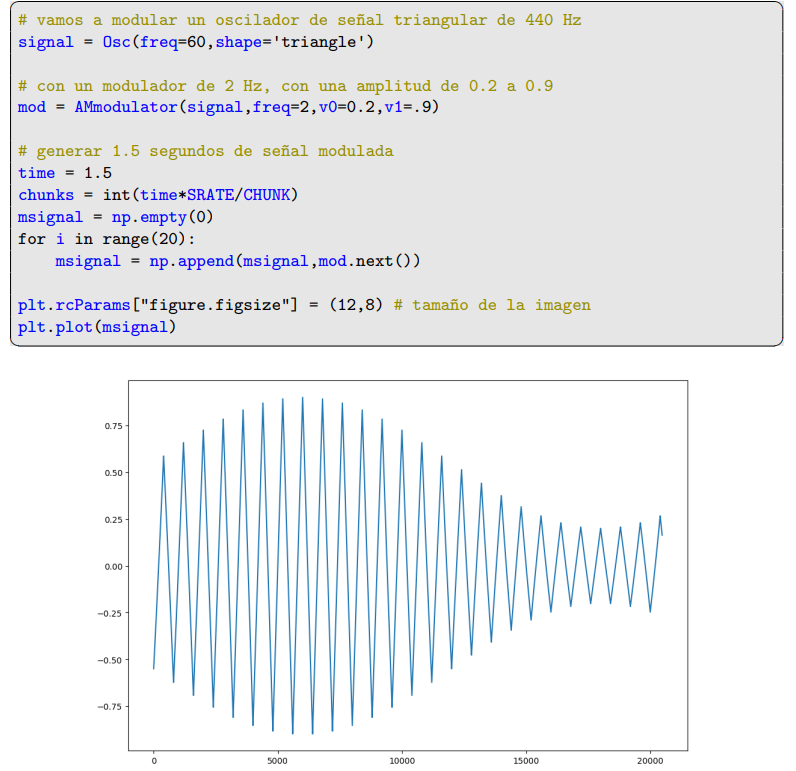

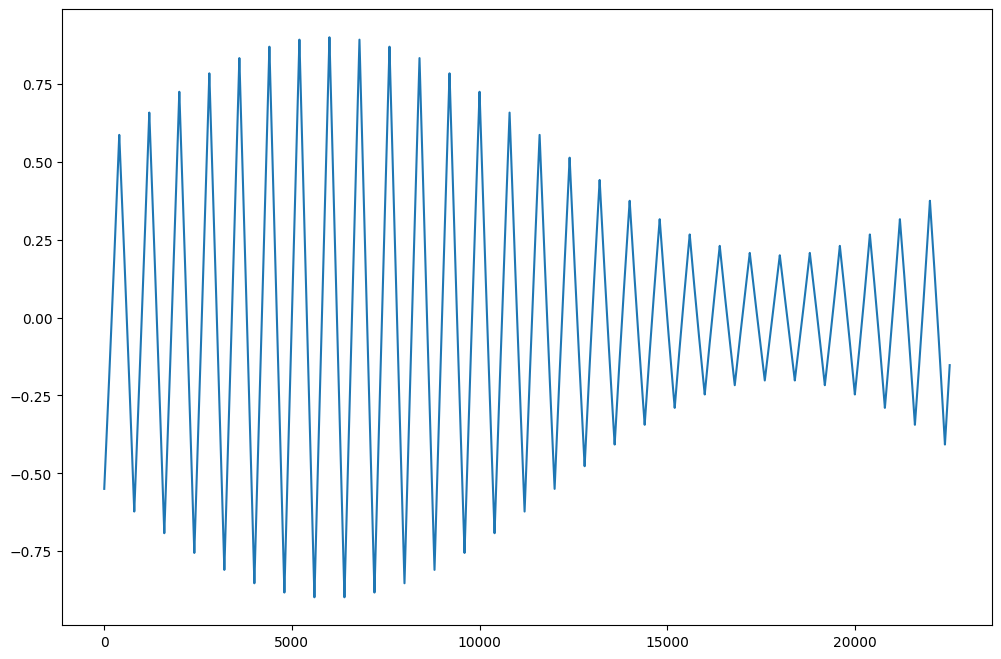

In [33]:
signal = Osc(60,shape='triangle')

class AMmodulator:
    def __init__(self, signal, shape = 'sin', freq = 1, v0 = 0, v1 = 1):
        self.signal = signal
        self.shape = shape
        self.freq = freq
        self.v0 = v0
        self.v1 = v1
        self.osc = Osc(freq, shape=shape)

    def next(self):
         mod = self.osc.next()
         mod = mod * (self.v1-self.v0)/2 + (self.v0+(self.v1-self.v0)/2)
         return np.float32(self.signal.next() * mod)
        
modulator = AMmodulator(signal,freq=2,v0=0.2,v1=0.9)

time = 0.5
chunks = int(time*SRATE/CHUNK)
mSignal = np.empty(0)
for i in range(chunks):
    mSignal = np.append(mSignal, modulator.next())

plt.rcParams["figure.figsize"] = (12,8)
plt.plot(mSignal)
sd.play(mSignal)

